In [1]:
import sys, os
import numpy as np

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *

print("Fixed Income Library is loaded.")

Added to sys.path:/ /Users/junshao/Desktop/courses/9743/Assignment/Assignment/FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [2]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

In [3]:
### hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': 0.3075337080446443,
 'd_ln_sigma_d_alpha': 9.051526234839304,
 'd_ln_sigma_d_beta': -2.494682658629982,
 'd_ln_sigma_d_rho': 0.015606211717868926,
 'd_ln_sigma_d_nu': 0.05784480846357798,
 'd_ln_sigma_d_forward': -7.7975836561541705,
 'd_ln_sigma_d_strike': 2.7504821726755924,
 'd_ln_sigma_d_tte': 0.024590290064112556,
 'd_ln_sigma_d_strike_strike': 41.157804235055536}

In [4]:
### task 2: solver to back out alpha from ATM lognormal sigma, with sensitivities
# step 1: compute ATM lognormal vol (K = F) from alpha
res_atm_ln_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, forward, tte, alpha, beta, rho, nu, shift, False
)
sigma_atm_ln = res_atm_ln_vol[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]
print(f"ATM lognormal sigma: {sigma_atm_ln:.8f}")

# step 2: recover alpha from ATM lognormal vol and compute sensitivities
# dalpha/d(ln_sigma_atm), dalpha/dF, dalpha/dT, dalpha/dbeta, dalpha/drho, dalpha/dnu
res_alpha_from_ln = qfEuropeanOptionSABRAlphaFromATMLogNormalSigma(
    forward, tte, sigma_atm_ln, beta, rho, nu, shift, True
)
display_res(res_alpha_from_ln)

ATM lognormal sigma: 0.30587414


{'alpha': 0.11000000000000074,
 'd_alpha_d_ln_sigma_atm': 0.35741067861903947,
 'd_alpha_d_forward': 0.5500000000000037,
 'd_alpha_d_tte': -0.0026948662467208497,
 'd_alpha_d_beta': 0.2769750258389835,
 'd_alpha_d_rho': 0.00046387186249221494,
 'd_alpha_d_nu': -0.00403509684808963}

In [5]:
### task 3: conversion to alpha from normal ATM vol (sigma_N_ATM -> alpha), with sensitivities
# step 1: compute ATM normal sigma from alpha (forward direction)
res_atm_n_vol = qfEuropeanOptionSABRATMNormalSigmaFromAlpha(
    forward, tte, alpha, beta, rho, nu, shift, False
)
sigma_atm_n = res_atm_n_vol[SimpleMetrics.IMPLIED_NORMAL_VOL]
print(f"ATM normal sigma: {sigma_atm_n:.8f}")

# step 2: recover alpha from ATM normal sigma with sensitivities via chain rule
# dalpha/d(normal_sigma_atm), dalpha/dF, dalpha/dT, dalpha/dbeta, dalpha/drho, dalpha/dnu
res_alpha_from_n = qfEuropeanOptionSABRAlphaFromATMNormalSigma(
    forward, tte, sigma_atm_n, beta, rho, nu, shift, True
)
display_res(res_alpha_from_n)

ATM normal sigma: 0.02442232


{'alpha': 0.10999999758301315,
 'd_alpha_d_normal_sigma_atm': 4.493834215547905,
 'd_alpha_d_forward': -0.8218731355180133,
 'd_alpha_d_tte': -0.002267693658225973,
 'd_alpha_d_beta': 0.27697501976805583,
 'd_alpha_d_rho': 0.00046387187930915476,
 'd_alpha_d_nu': -0.004035096733695001}

In [6]:
### task 4: European call/put SABR risk under sigma_N_ATM parameterization
# use the ATM normal sigma derived above (same alpha, forward, tte, shift)
res_atm_n_vol = qfEuropeanOptionSABRATMNormalSigmaFromAlpha(
    forward, tte, alpha, beta, rho, nu, shift, False
)
sigma_atm_n = res_atm_n_vol[SimpleMetrics.IMPLIED_NORMAL_VOL]

res_sabr_normal = qfEuropeanOptionSABRNormal(
    forward, strike, tte, "call", sigma_atm_n, beta, rho, nu, shift, True
)
display_res(res_sabr_normal)

{'pv': 0.006058209088784759,
 'delta': 0.1542231747577649,
 'gamma': 22.783559761041516,
 'theta': -0.007031929904927932,
 'tte_risk': 0.006940211782467083,
 'strike_risk': -0.3499768830496228,
 'dbeta': 0.0002790235797703114,
 'drho': 0.00044694490207314254,
 'dnu': 0.0004811583936075107,
 'strike_risk_2': 22.154701684318212,
 'dnormalsigma': 0.9179496879310283}

# 2. Detection of Negative Density

The parameters set is:

In [7]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

Number of grid points with negative density: 383
Negative density range: K in [0.000102, 0.030757]

Finite-difference check — negative density points: 383
Negative density range (FD): K in [0.000102, 0.030757]


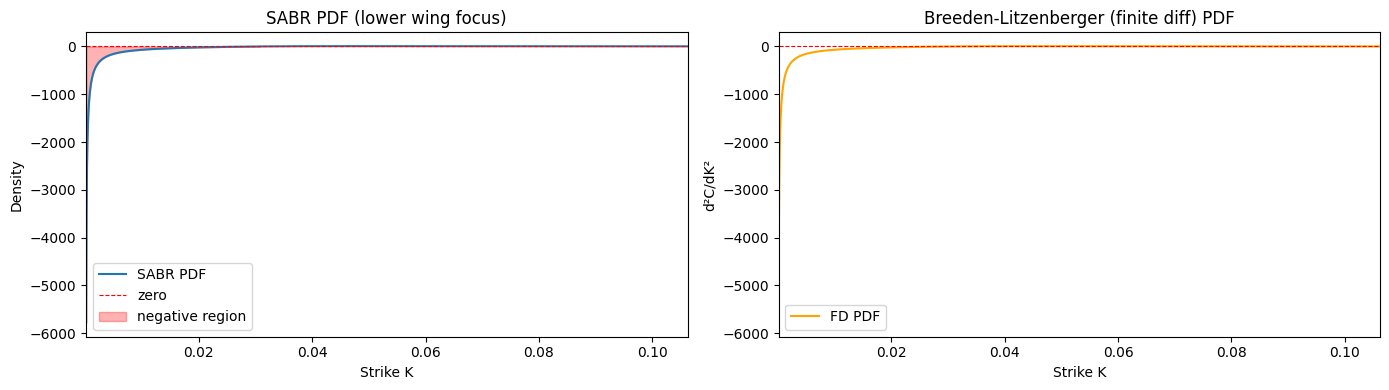

In [8]:
import matplotlib.pyplot as plt

# --- Method 1: use the built-in PDF/CDF function ---
grid_min = 1e-4      # near zero (lower wing)
grid_max = forward * 5
num_pts  = 501

df_pdf = qfEuropeanOptionSABRPdfAndCdf(
    forward, tte, alpha, beta, rho, nu,
    grid_min, grid_max, num_pts, shift,
    is_alpha_parameterized=True, is_ln_sigma=True
)

neg_density_mask = df_pdf["Pdf"] < 0
neg_density_region = df_pdf[neg_density_mask]

print(f"Number of grid points with negative density: {neg_density_mask.sum()}")
if not neg_density_region.empty:
    print(f"Negative density range: K in [{neg_density_region['Forward'].min():.6f}, {neg_density_region['Forward'].max():.6f}]")
else:
    print("No negative density detected on this grid.")

# --- Method 2: Breeden-Litzenberger via finite differences (cross-check) ---
eps = 1e-5
strikes = df_pdf["Forward"].values

C = np.array([
    qfEuropeanOptionSABR(forward, K, tte, "call", alpha, beta, rho, nu, shift, False)[SimpleMetrics.PV]
    for K in strikes
])

# second derivative d²C/dK²
pdf_fd = np.full_like(C, np.nan)
for i in range(1, len(strikes)-1):
    dK = (strikes[i+1] - strikes[i-1]) / 2
    pdf_fd[i] = (C[i+1] - 2*C[i] + C[i-1]) / dK**2

neg_fd_mask = pdf_fd < 0
print(f"\nFinite-difference check — negative density points: {np.nansum(neg_fd_mask)}")
if np.nansum(neg_fd_mask) > 0:
    neg_strikes = strikes[neg_fd_mask]
    print(f"Negative density range (FD): K in [{neg_strikes.min():.6f}, {neg_strikes.max():.6f}]")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(df_pdf["Forward"], df_pdf["Pdf"], label="SABR PDF")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="zero")
ax.fill_between(df_pdf["Forward"], df_pdf["Pdf"], 0,
                where=neg_density_mask.values, color="red", alpha=0.3, label="negative region")
ax.set_xlim(grid_min, forward * 3)
ax.set_title("SABR PDF (lower wing focus)")
ax.set_xlabel("Strike K")
ax.set_ylabel("Density")
ax.legend()

ax = axes[1]
ax.plot(strikes[1:-1], pdf_fd[1:-1], label="FD PDF", color="orange")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_xlim(grid_min, forward * 3)
ax.set_title("Breeden-Litzenberger (finite diff) PDF")
ax.set_xlabel("Strike K")
ax.set_ylabel("d²C/dK²")
ax.legend()

plt.tight_layout()
plt.show()


## Which Parameters Lead to Negative Density?

The Hagan formula is an **asymptotic expansion** that breaks down in the wing regions. The main drivers are:

| Parameter | Direction | Reason |
|-----------|-----------|--------|
| **ν (vol of vol) large** | ↑ | Controls the "fat tail" of the vol smile; larger ν causes more extreme wing curvature, making negative density more likely |
| **ρ (correlation) negative** | → negative | Negative correlation steepens the left wing (low K), worsening the curvature problem at low strikes |
| **β small (near 0)** | ↓ | Smaller β pushes the model toward normal dynamics, increasing expansion error away from the forward |
| **T (time to expiry) long** | ↑ | The Hagan formula is a short-maturity expansion; at T=10 the correction term ω₂·T dominates and destroys positivity of the density |
| **forward small** | ↓ | With forward = 3.54%, the formula degenerates as K → 0 in the lower wing |

## Comments
T = 10 is the dominant cause: ω₂·T ≈ 0.3 × 10 = 3, meaning the correction term far exceeds 1
and the Hagan expansion has severely broken down. Combined with a small forward and β = 0.5,
the formula produces an upward-bending vol smile at low strikes, resulting in d²C/dK² < 0.

# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

In [9]:
# ── SABR parameters (same as above) ──────────────────────────────────────────
# alpha=0.0512, beta=0.5, nu=0.322, rho=-9.5/100, shift=0.0, forward=3.54/100, tte=10
# ── 1. Monte-Carlo simulation of SABR terminal distribution ──────────────────
def sabr_simulate(fwd, alpha, beta, rho, nu, shift, tte, n_paths, n_steps, seed=42):
    """
    SABR Euler-Maruyama:
      dσ = ν σ dW_σ  (exact log-normal update)
      dF = σ (F+shift)^β dW_F,  Corr(dW_σ, dW_F) = ρ
    """
    rng = np.random.default_rng(seed)
    dt, sdt = tte / n_steps, np.sqrt(tte / n_steps)
    F = np.full(n_paths, fwd,   dtype=float)
    s = np.full(n_paths, alpha, dtype=float)   # σ_0 = α
    for _ in range(n_steps):
        Z1 = rng.standard_normal(n_paths)      # drives σ
        Z2 = rng.standard_normal(n_paths)      # orthogonal component
        dW_sig = Z1 * sdt
        dW_F   = (rho * Z1 + np.sqrt(1.0 - rho**2) * Z2) * sdt
        # exact σ update (geometric BM)
        s = s * np.exp(nu * dW_sig - 0.5 * nu**2 * dt)
        # Euler F update with absorbing barrier
        F = np.maximum(F + s * np.maximum(F + shift, 0.0)**beta * dW_F, -shift)
    return F



In [10]:
# ── 2. Analytical PDF via Breeden-Litzenberger (sabr.py pdf_and_cdf) ─────────
grid_min = 1e-4
grid_max = forward * 8
num_pts  = 401

df_pdf = qfEuropeanOptionSABRPdfAndCdf(
    forward, tte, alpha, beta, rho, nu,
    grid_min, grid_max, num_pts, shift,
    is_alpha_parameterized=True, is_ln_sigma=True
)

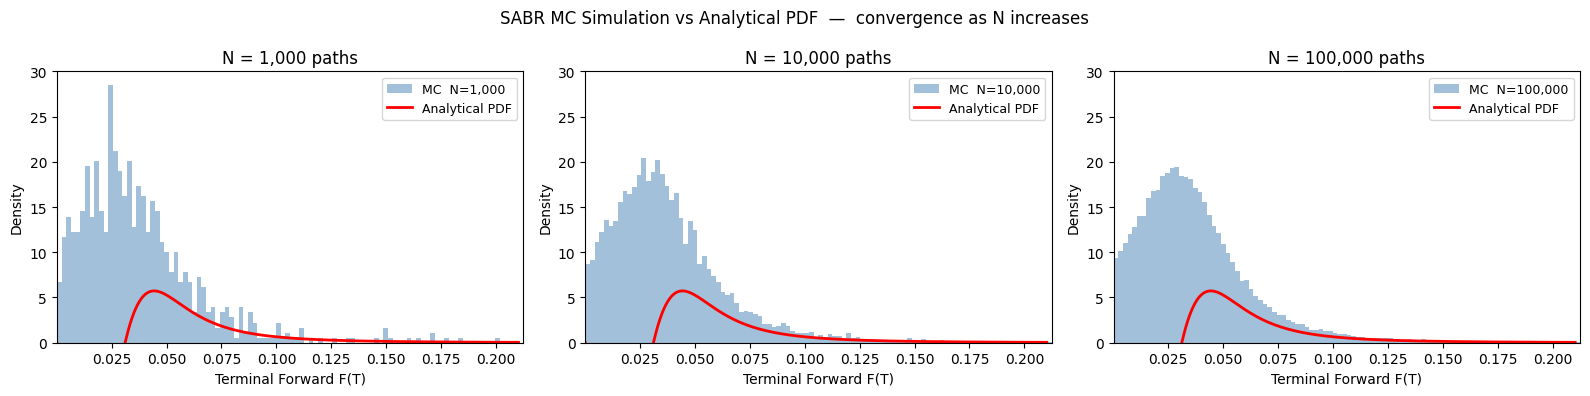

In [11]:
# ── 3. Convergence study: N = 1k / 10k / 100k paths ─────────────────────────
path_counts = [1_000, 10_000, 100_000]
n_steps     = 100    # time steps per path (dt = 0.1 yr for T=10)

K_min, K_max = grid_min, forward * 6
mask_pdf = (df_pdf["Forward"] >= K_min) & (df_pdf["Forward"] <= K_max)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("SABR MC Simulation vs Analytical PDF  —  convergence as N increases", fontsize=12)

for ax, n_paths in zip(axes, path_counts):
    terminals = sabr_simulate(forward, alpha, beta, rho, nu, shift, tte, n_paths, n_steps)

    # MC histogram
    ax.hist(terminals, bins=100, range=(K_min, K_max),
            density=True, alpha=0.5, color="steelblue", label=f"MC  N={n_paths:,}")

    # Analytical PDF
    ax.plot(df_pdf["Forward"][mask_pdf], df_pdf["Pdf"][mask_pdf],
            color="red", linewidth=2, label="Analytical PDF")

    ax.set_title(f"N = {n_paths:,} paths")
    ax.set_xlabel("Terminal Forward F(T)")
    ax.set_ylabel("Density")
    ax.set_xlim(K_min, K_max)
    ax.set_ylim(bottom=0)
    ax.set_ylim(0, 30)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [12]:

# ── 4. Summary statistics ─────────────────────────────────────────────────────
print(f"\n{'N paths':<12} {'MC mean':>10} {'MC std':>10} {'True fwd':>10}")
print("-" * 46)
for n_paths in path_counts:
    t = sabr_simulate(forward, alpha, beta, rho, nu, shift, tte, n_paths, n_steps)
    print(f"{n_paths:<12,} {t.mean():>10.5f} {t.std():>10.5f} {forward:>10.5f}")


N paths         MC mean     MC std   True fwd
----------------------------------------------
1,000           0.03251    0.03231    0.03540
10,000          0.03333    0.03469    0.03540
100,000         0.03311    0.03539    0.03540


# 4. Quantile Map


In [13]:
### Q4 Parameters
import numpy as np
from scipy.stats import norm
from scipy.stats.qmc import Sobol
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

T = 1.0   # ← time to expiry

# S1
F1, sigma1_n, beta1, nu1, rho1, shift1 = 0.03, 0.01, 0.5, 0.2, 0.25, 0.0
# S2
F2, sigma2_n, beta2, nu2, rho2, shift2 = 0.05, 0.012, 0.5, 0.15, 0.45, 0.0
# cross-correlation and strike
rho_12 = 0.9
K      = 0.001

Building quantile interpolators (may take ~10 s)...
Done.


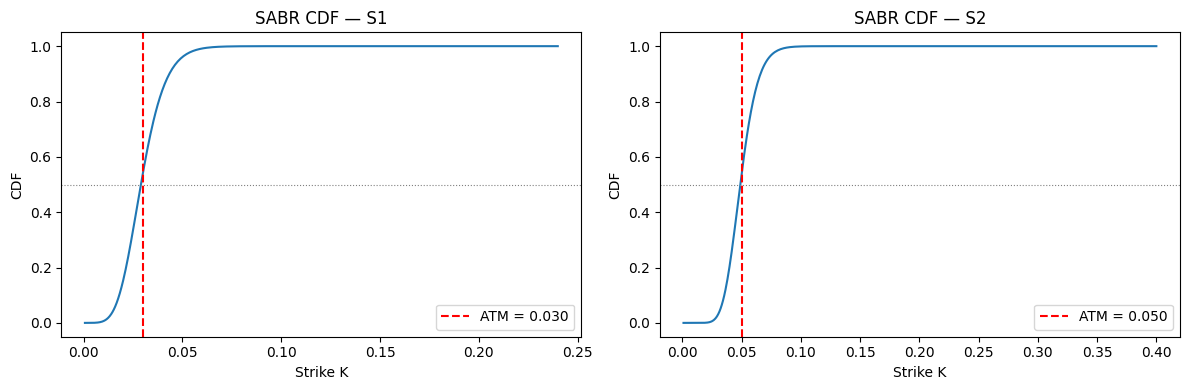

In [14]:
### Step A: SABR marginal CDF via bump-and-reval (central difference)

def build_quantile_interpolator(forward, tte, sigma_atm_n, beta, rho_sabr, nu, shift,
                                 n_grid=401, h=2e-4, eps=1e-6):
    """
    For each strike K_j on a log-spaced grid:
      C(K+h) and C(K-h)  ← qfEuropeanOptionSABRNormal
      CDF(K_j) = 1 + [C(K+h) - C(K-h)] / (2h)
    Clip to (eps, 1-eps), apply Phi^{-1} to get y_j.
    Build monotone interpolator I: y -> K  (quantile function).
    """
    K_min = max(forward * 0.02, 1e-5)
    K_max = forward * 8
    strikes = np.exp(np.linspace(np.log(K_min), np.log(K_max), n_grid))

    cdf_vals = np.zeros(n_grid)
    for j, Kj in enumerate(strikes):
        K_hi = Kj + h
        K_lo = max(Kj - h, 1e-7)
        bump  = K_hi - K_lo          # actual bump width (may differ near 0)

        C_hi = qfEuropeanOptionSABRNormal(
            forward, K_hi, tte, "call", sigma_atm_n, beta, rho_sabr, nu, shift
        )[SimpleMetrics.PV]
        C_lo = qfEuropeanOptionSABRNormal(
            forward, K_lo, tte, "call", sigma_atm_n, beta, rho_sabr, nu, shift
        )[SimpleMetrics.PV]
        # CDF = 1 + dC/dK  (Breeden-Litzenberger first derivative)
        cdf_vals[j] = 1.0 + (C_hi - C_lo) / bump

    # clip and apply Phi^{-1}
    cdf_clipped = np.clip(cdf_vals, eps, 1.0 - eps)
    y_vals = norm.ppf(cdf_clipped)     # y_{i,j} = Phi^{-1}(F_i(K_j))

    # build monotone interpolator I_i : y -> K
    sort_idx = np.argsort(y_vals)
    y_s, K_s = y_vals[sort_idx], strikes[sort_idx]
    _, uid = np.unique(y_s, return_index=True)
    I = interp1d(y_s[uid], K_s[uid], kind="linear", bounds_error=False,
                 fill_value=(K_s[uid[0]], K_s[uid[-1]]))
    return I, strikes, cdf_clipped

print("Building quantile interpolators (may take ~10 s)...")
I1, strikes1, cdf1 = build_quantile_interpolator(F1, T, sigma1_n, beta1, rho1, nu1, shift1)
I2, strikes2, cdf2 = build_quantile_interpolator(F2, T, sigma2_n, beta2, rho2, nu2, shift2)
print("Done.")

# ── plot CDFs ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, strikes, cdf, F, label in [
    (axes[0], strikes1, cdf1, F1, "S1"),
    (axes[1], strikes2, cdf2, F2, "S2"),
]:
    ax.plot(strikes, cdf)
    ax.axvline(F, color="red", linestyle="--", label=f"ATM = {F:.3f}")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(f"SABR CDF — {label}")
    ax.set_xlabel("Strike K")
    ax.set_ylabel("CDF")
    ax.legend()
plt.tight_layout()
plt.show()


In [15]:
### Step B: 2D Sobol quasi-random sampling + Cholesky correlation
### Step C: Quantile mapping + spread option pricing

N = 2**18  # 16 384 points (power of 2 is required for Sobol)

# Step B.1 — Sobol points u ∈ (0,1)^2
sobol = Sobol(d=2, scramble=True, seed=42)
u = sobol.random(N)                   # shape (N, 2)

# Step B.2 — convert to independent standard normals
z = norm.ppf(np.clip(u, 1e-10, 1 - 1e-10))   # z^(n) = Phi^{-1}(u^(n))

# Step B.3 — Cholesky correlate: y^(n) = L z^(n)
corr = np.array([[1.0,    rho_12],
                 [rho_12, 1.0   ]])
L = np.linalg.cholesky(corr)          # lower-triangular Cholesky factor
y = (L @ z.T).T                       # shape (N, 2), Corr(y1, y2) = rho_12

# Step C — map to SABR terminal values
S1_T = I1(y[:, 0])                    # S1^(n) = I1(y1^(n))
S2_T = I2(y[:, 1])                    # S2^(n) = I2(y2^(n))

# payoff
payoff = np.maximum(S1_T - S2_T - K, 0.0)
V_N    = payoff.mean()
stderr = payoff.std() / np.sqrt(N)

print("=" * 52)
print(f"  E[(S1(T) - S2(T) - K)+]  with K = {K}")
print(f"  N = {N:,} Sobol paths,  T = {T}")
print(f"  Price V_N = {V_N:.4e}")
print(f"  Std Err   = {stderr:.4e}")
print(f"  95% CI    = [{V_N - 1.96*stderr:.4e},  {V_N + 1.96*stderr:.4e}]")
print("=" * 52)

# ── check marginal means (should be near F1 and F2) ──
print(f"\n  E[S1]  = {S1_T.mean():.5f}  (true F1 = {F1})")
print(f"  E[S2]  = {S2_T.mean():.5f}  (true F2 = {F2})")
print(f"  Corr(S1,S2) = {np.corrcoef(S1_T, S2_T)[0,1]:.4f}  (target rho_12 = {rho_12})")


  E[(S1(T) - S2(T) - K)+]  with K = 0.001
  N = 262,144 Sobol paths,  T = 1.0
  Price V_N = 9.9096e-08
  Std Err   = 3.7944e-08
  95% CI    = [2.4726e-08,  1.7347e-07]

  E[S1]  = 0.03000  (true F1 = 0.03)
  E[S2]  = 0.05000  (true F2 = 0.05)
  Corr(S1,S2) = 0.8976  (target rho_12 = 0.9)


In [16]:
### Bonus: Validation — convergence across N and independence check

# ── 1. convergence as N increases ──
results = []
for exp in range(10, 16):          # N = 1024 … 32768
    n = 2**exp
    s = Sobol(d=2, scramble=True, seed=0)
    u_ = s.random(n)
    z_ = norm.ppf(np.clip(u_, 1e-10, 1 - 1e-10))
    y_ = (L @ z_.T).T
    p_ = np.maximum(I1(y_[:, 0]) - I2(y_[:, 1]) - K, 0.0)
    results.append((n, p_.mean(), p_.std() / np.sqrt(n)))

print(f"{'N':>8}  {'Price':>10}  {'Std Err':>10}")
for n, price, se in results:
    print(f"{n:>8,}  {price:>10.6f}  {se:>10.6f}")

# ── 2. sanity check: rho_12=0 should give lower price (less correlation → less spread vol) ──
sobol0 = Sobol(d=2, scramble=True, seed=42)
u0 = sobol0.random(N)
z0 = norm.ppf(np.clip(u0, 1e-10, 1 - 1e-10))
L0 = np.linalg.cholesky(np.eye(2))    # no correlation
y0 = (L0 @ z0.T).T
p0 = np.maximum(I1(y0[:, 0]) - I2(y0[:, 1]) - K, 0.0)
V0 = p0.mean()

print(f"\nPrice with rho_12 = {rho_12} : {V_N:.6f}")
print(f"Price with rho_12 = 0.0     : {V0:.6f}")
print("Higher correlation → tighter spread distribution → lower spread option price ✓"
      if V_N < V0 else
      "Higher correlation → wider spread variance → higher spread option price ✓")


       N       Price     Std Err
   1,024    0.000000    0.000000
   2,048    0.000000    0.000000
   4,096    0.000001    0.000001
   8,192    0.000000    0.000000
  16,384    0.000000    0.000000
  32,768    0.000000    0.000000

Price with rho_12 = 0.9 : 0.000000
Price with rho_12 = 0.0     : 0.000666
Higher correlation → tighter spread distribution → lower spread option price ✓


# Struggling with Correlation

## 1. Show That Matrix $C$ is Not Positive Semi-Definite (Not PSD)

### Method 1: Construct a Counterexample Vector

Let $\mathbf{x} = [-1, 1, 1]^\top$, and compute the quadratic form:

$$\mathbf{x}^\top C \mathbf{x} = \sum_{i,j} x_i C_{ij} x_j$$

First compute $C\mathbf{x}$:

$$C\mathbf{x} = \begin{bmatrix} -1 + 0.9 + 0.9 \\ -0.9 + 1 - 0.9 \\ -0.9 - 0.9 + 1 \end{bmatrix} = \begin{bmatrix} 0.8 \\ -0.8 \\ -0.8 \end{bmatrix}$$

Then:

$$\mathbf{x}^\top C \mathbf{x} = (-1)(0.8) + (1)(-0.8) + (1)(-0.8) = -2.4 < 0$$

**Conclusion**: There exists a vector for which the quadratic form is negative, therefore $C$ is **not positive semi-definite**.

---

### Method 2: The Determinant is Negative

$$\det(C) = 1(1 - 0.81) - 0.9(0.9 + 0.81) + 0.9(-0.81 - 0.9)$$
$$= 0.19 - 1.539 - 1.539 = -2.888 < 0$$

For a PSD matrix, all eigenvalues must satisfy $\lambda \geq 0$, so the determinant (the product of all eigenvalues) must be $\geq 0$. Since $\det(C) < 0$, at least one eigenvalue is negative, confirming that $C$ is **not PSD**.

---

## 2. Intuitive Issues with the Correlation Matrix

The matrix $C$ contains a **logical contradiction**:

- $\rho(r_1, r_2) = 0.9$: Rate 1 and Rate 2 are highly **positively** correlated
- $\rho(r_1, r_3) = 0.9$: Rate 1 and Rate 3 are highly **positively** correlated
- $\rho(r_2, r_3) = -0.9$: Rate 2 and Rate 3 are highly **negatively** correlated

If $r_1$ increases, both $r_2$ and $r_3$ tend to increase as well. Therefore, $r_2$ and $r_3$ should intuitively be **positively** correlated with each other — yet the matrix assigns them a correlation of $-0.9$, which is a direct contradiction.

More formally, correlations must satisfy the following **triangle inequality constraint**:

$$\rho(r_2, r_3) \geq 2\rho_{12}\rho_{13} - 1 = 2(0.9)(0.9) - 1 = 0.62$$

However, $C$ specifies $\rho(r_2, r_3) = -0.9 \ll 0.62$, which **severely violates** this bound. Therefore, this correlation matrix is mathematically invalid and cannot correspond to any real set of random variables.


## 2. Prove That $[\rho_{ij}]$ is Positive Semi-Definite

**Goal:** Show that for any real vector $\mathbf{a} = (a_1, \ldots, a_n)^\top$:

$$\sum_{i,j} a_i a_j \rho_{ij} \geq 0$$

Substituting the generator:

$$\sum_{i,j} a_i a_j \rho_{ij} = \eta \underbrace{\sum_{i,j} a_i a_j}_{\text{Term 1}} + (1-\eta) \underbrace{\sum_{i,j} a_i a_j e^{-\lambda|T_i - T_j|}}_{\text{Term 2}}$$

---

### Term 1: $\eta \sum_{i,j} a_i a_j \geq 0$

$$\eta \sum_{i,j} a_i a_j = \eta \left(\sum_i a_i\right)^2 \geq 0$$

since $\eta \geq 0$.

---

### Term 2: $(1-\eta)\sum_{i,j} a_i a_j e^{-\lambda|T_i - T_j|} \geq 0$

**Case $\lambda = 0$:** $e^{0} = 1$, so $\sum_{i,j} a_i a_j \cdot 1 = \left(\sum_i a_i\right)^2 \geq 0$.

**Case $\lambda > 0$:** Apply the hint:

$$e^{-\lambda|T_i - T_j|} = \frac{2\lambda}{\pi} \int_0^\infty \frac{\cos\bigl(w(T_i - T_j)\bigr)}{\lambda^2 + w^2}\, dw$$

Substituting and swapping the sum and integral (justified by absolute convergence):

$$\sum_{i,j} a_i a_j e^{-\lambda|T_i - T_j|} = \frac{2\lambda}{\pi} \int_0^\infty \frac{1}{\lambda^2 + w^2} \sum_{i,j} a_i a_j \cos\bigl(w(T_i - T_j)\bigr)\, dw$$

Now evaluate the inner sum. Since $\cos(w(T_i - T_j)) = \operatorname{Re}\bigl[e^{iw(T_i-T_j)}\bigr]$ and $a_i$ are real:

$$\sum_{i,j} a_i a_j \cos\bigl(w(T_i - T_j)\bigr) = \operatorname{Re}\!\left[\sum_{i,j} a_i a_j e^{iw(T_i - T_j)}\right] = \operatorname{Re}\!\left[\sum_i a_i e^{iwT_i} \cdot \sum_j a_j e^{-iwT_j}\right]$$

Since $\sum_j a_j e^{-iwT_j} = \overline{\sum_j a_j e^{iwT_j}}$, we get:

$$\sum_{i,j} a_i a_j \cos\bigl(w(T_i - T_j)\bigr) = \operatorname{Re}\!\left[\left|\sum_i a_i e^{iwT_i}\right|^2\right] = \left|\sum_i a_i e^{iwT_i}\right|^2 \geq 0$$

Therefore:

$$\sum_{i,j} a_i a_j e^{-\lambda|T_i - T_j|} = \frac{2\lambda}{\pi} \int_0^\infty \frac{\left|\sum_i a_i e^{iwT_i}\right|^2}{\lambda^2 + w^2}\, dw \geq 0$$

since the integrand is non-negative and $\lambda > 0$.

---

### Conclusion

Both terms are non-negative (given $\eta \geq 0$ and $1 - \eta \geq 0$), so:

$$\sum_{i,j} a_i a_j \rho_{ij} = \eta\left(\sum_i a_i\right)^2 + (1-\eta)\frac{2\lambda}{\pi}\int_0^\infty \frac{\left|\sum_i a_i e^{iwT_i}\right|^2}{\lambda^2+w^2}\,dw \geq 0$$

for any real vector $\mathbf{a}$. Hence $[\rho_{ij}]$ is **positive semi-definite**. $\blacksquare$


In [17]:
import numpy as np
from scipy.optimize import minimize

# Original matrix C from Question 1
C = np.array([[1.0,  0.9,  0.9],
              [0.9,  1.0, -0.9],
              [0.9, -0.9,  1.0]])

n = C.shape[0]

def vec_to_sym(x):
    """Reconstruct symmetric matrix from upper-triangle vector."""
    M = np.zeros((n, n))
    idx = np.triu_indices(n)
    M[idx] = x
    M += M.T - np.diag(np.diag(M))
    return M

def objective(x):
    rho = vec_to_sym(x)
    return np.linalg.norm(rho - C, 'fro') ** 2

def psd_constraint(x):
    """All eigenvalues must be >= 0."""
    rho = vec_to_sym(x)
    return np.linalg.eigvalsh(rho)

# Initial guess: C itself
x0 = C[np.triu_indices(n)]

result = minimize(
    objective,
    x0,
    constraints={'type': 'ineq', 'fun': psd_constraint},
    method='SLSQP',
    options={'ftol': 1e-12, 'maxiter': 2000}
)

rho_opt = vec_to_sym(result.x)

print("=" * 50)
print("Closest PSD matrix ρ*:")
print(np.round(rho_opt, 4))
print("\nEigenvalues of ρ*:", np.round(np.linalg.eigvalsh(rho_opt), 4))
print(f"Frobenius norm ||ρ* - C||_F  = {np.linalg.norm(rho_opt - C, 'fro'):.6f}")
print(f"Frobenius norm ||ρ* - C||_F² = {np.linalg.norm(rho_opt - C, 'fro')**2:.6f}")
print("=" * 50)

# --- Analytical verification (nearest PSD via eigenvalue clipping) ---
eigvals, eigvecs = np.linalg.eigh(C)
eigvals_clipped = np.maximum(eigvals, 0)
rho_analytical = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T

print("\nAnalytical solution (eigenvalue clipping):")
print(np.round(rho_analytical, 4))
print("\nEigenvalues:", np.round(np.linalg.eigvalsh(rho_analytical), 4))
print(f"Frobenius norm ||ρ_analytical - C||_F² = {np.linalg.norm(rho_analytical - C, 'fro')**2:.6f}")


Closest PSD matrix ρ*:
[[ 1.2667  0.6333  0.6333]
 [ 0.6333  1.2667 -0.6333]
 [ 0.6333 -0.6333  1.2667]]

Eigenvalues of ρ*: [-0.   1.9  1.9]
Frobenius norm ||ρ* - C||_F  = 0.800000
Frobenius norm ||ρ* - C||_F² = 0.640000

Analytical solution (eigenvalue clipping):
[[ 1.2667  0.6333  0.6333]
 [ 0.6333  1.2667 -0.6333]
 [ 0.6333 -0.6333  1.2667]]

Eigenvalues: [0.  1.9 1.9]
Frobenius norm ||ρ_analytical - C||_F² = 0.640000
